In [41]:
import torch
import torchvision.models as tvm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

import sys; sys.path.append("../src/")
from banal import sample_level_k_fourier_info
from data_utils import ImageDataset, TweetEvalDataset
from models import SmoothedImageClassifier, SmoothedTextClassifier
from transformers import RobertaForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

In [32]:
class BinarizedMaskedTextClassifier(torch.nn.Module):
    def __init__(self, masked_text_classifier, input_ids):
        super().__init__()
        self.masked_text_classifier = masked_text_classifier
        self.register_buffer("input_ids", input_ids.view(-1))

    def forward(self, alpha):
        print(self.input_ids.shape, alpha.shape)
        input_ids = self.input_ids.unsqueeze(0).repeat(alpha.size(0), 1)
        return self.masked_text_classifier(input_ids=input_ids, attention_mask=alpha)

In [43]:
raw_text_model = SmoothedTextClassifier(
    RobertaForSequenceClassification.from_pretrained("cardiffnlp/roberta-base-sentiment"),
    lambda_ = 0.8,
    num_samples = 16
)

In [44]:
dataset = TweetEvalDataset("sentiment", "/home/antonxue/foo/data/tweeteval/datasets")
item = dataset[0]

In [45]:
inputs, _ = item
input_ids = inputs["input_ids"]
input_ids.shape

torch.Size([1, 21])

In [46]:
bin_text_model = BinarizedMaskedTextClassifier(raw_text_model, input_ids)

In [47]:
out = bin_text_model(torch.randint(0,2, (7,input_ids.size(1))))
out.shape

torch.Size([21]) torch.Size([7, 21])


torch.Size([7, 3])

In [2]:
dataset = ImageDataset("/home/antonxue/foo/data/imagenet_samples/imagenet_2_per_class/")
image = dataset[0]

In [3]:
class BinarizedMaskedImageClassifier(torch.nn.Module):
    def __init__(self, masked_image_classifier, image):
        super().__init__()
        self.masked_image_classifier = masked_image_classifier
        self.register_buffer("image", image); assert image.ndim == 3
        
    def forward(self, alpha):
        x = self.image.unsqueeze(0).repeat(alpha.size(0), 1, 1, 1)
        return self.masked_image_classifier(x, alpha)

In [4]:
image.shape

torch.Size([3, 224, 224])

In [5]:
lambda_ = 1.0

raw_model = SmoothedImageClassifier(
    tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1),
    grid_size = (7, 7),
    lambda_ = lambda_
)

model = BinarizedMaskedImageClassifier(raw_model, image)
model.eval().to(device);

In [6]:
all_infos = []
n = 49
for k in tqdm(range(1, 49+1)):
    info = sample_level_k_fourier_info(model, n, k)
    all_infos.append(info)

  0%|          | 0/49 [00:00<?, ?it/s]

In [7]:
info0 = all_infos[0]
info1 = all_infos[1]
info2 = all_infos[2]

In [8]:
info0["average_variance"].shape, info0["average_mass"].shape, info0["coefficients"].shape

(torch.Size([1000]), torch.Size([1000]), torch.Size([1024, 1000]))

In [9]:
variances = np.array([info["average_variance"].max().cpu().numpy() for info in all_infos])
masses = np.array([info["average_mass"].max().cpu().numpy() for info in all_infos])

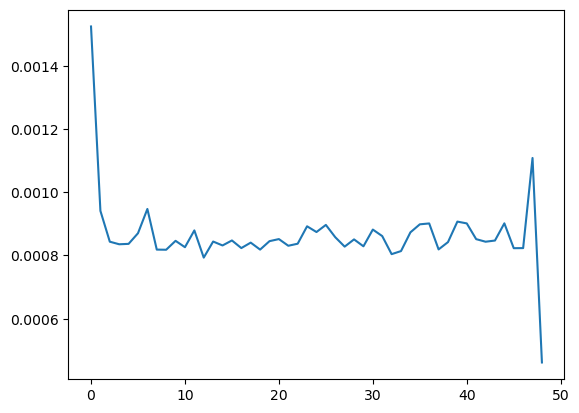

In [10]:
fig, ax = plt.subplots()
ax.plot(variances)

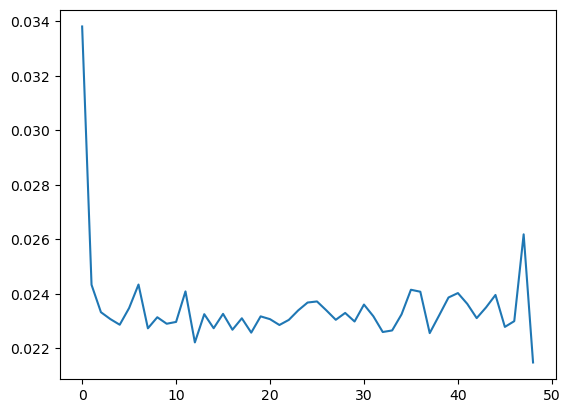

In [11]:
fig, ax = plt.subplots()
ax.plot(masses)